<a href="https://colab.research.google.com/github/jadenmeyer/CUDA-DFT-FFT/blob/main/ProjectRisk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Risk Simulation

In [9]:
import math as m
import random as rand
from re import S
from typing import Union,Tuple


class simulation:
  def __init__(self,cRate,sRate,rRate,pRate,cDist,iCap,iCust): # set up some initial prameters
    self.claimRate = cRate
    self.signRate = sRate
    self.remainRate = rRate
    self.payRate = pRate
    self.claimDistribution = cDist
    self.initialCapital = iCap
    self.initialCustomer = iCust

  def getNextEvent(self,numCustomer) -> Tuple[float, str]: #generate the next event happening
    rate_sign = self.signRate
    rate_leave = numCustomer * self.remainRate
    rate_claim = numCustomer * self.claimRate

    total_rate = rate_sign + rate_leave + rate_claim

    if total_rate <= 0:
      raise Exception("Invalid rate")

    u1 = rand.random()
    dt = -m.log(u1) / total_rate

    u2 = rand.random()
    prob_sign = rate_sign / total_rate
    prob_leave = rate_leave / total_rate

    if u2 < prob_sign:
        event_type = "sign"
    elif u2 < (prob_sign + prob_leave):
        event_type = "leave"
    else:
        event_type = "claim"

    return dt, event_type

  def runSimulation(self,time): # simulate for one run
    simTime = 0
    customerNum = self.initialCustomer
    capital = self.initialCapital
    while simTime < time:
      dt, event_type = self.getNextEvent(customerNum)
      simTime += dt
      capital += customerNum * self.payRate * dt
      if event_type == "sign":
          customerNum += 1
      elif event_type == "leave":
          customerNum -= 1
      elif event_type == "claim":
          capital -= self.claimDistribution()
      if capital < 0:
        return False
    return True

  def computeProbability(self,time,simCount): # aggregate simCount runs and find the ratio of success runs
    successCount = 0
    for i in range(simCount):
      if self.runSimulation(time):
        successCount += 1
    return successCount / simCount




<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_8013/2059437031.py:43: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Probability of Survival (Capital $\geq$ 0)')


Running 500 simulations per time point...
Time t=1 | Survival Rate: 0.9980
Time t=2 | Survival Rate: 0.8880
Time t=3 | Survival Rate: 0.7340
Time t=4 | Survival Rate: 0.6060
Time t=5 | Survival Rate: 0.5560
Time t=6 | Survival Rate: 0.4820
Time t=7 | Survival Rate: 0.4640
Time t=8 | Survival Rate: 0.4580
Time t=9 | Survival Rate: 0.4220
Time t=10 | Survival Rate: 0.3820
Time t=11 | Survival Rate: 0.4120
Time t=12 | Survival Rate: 0.4040
Time t=13 | Survival Rate: 0.3860
Time t=14 | Survival Rate: 0.3880
Time t=15 | Survival Rate: 0.3840
Time t=16 | Survival Rate: 0.4180
Time t=17 | Survival Rate: 0.3980
Time t=18 | Survival Rate: 0.3820
Time t=19 | Survival Rate: 0.3800
Time t=20 | Survival Rate: 0.3400
Time t=21 | Survival Rate: 0.3720
Time t=22 | Survival Rate: 0.3580
Time t=23 | Survival Rate: 0.3240
Time t=24 | Survival Rate: 0.3240
Time t=25 | Survival Rate: 0.3400
Time t=26 | Survival Rate: 0.3640
Time t=27 | Survival Rate: 0.2920
Time t=28 | Survival Rate: 0.3240
Time t=29 | Sur

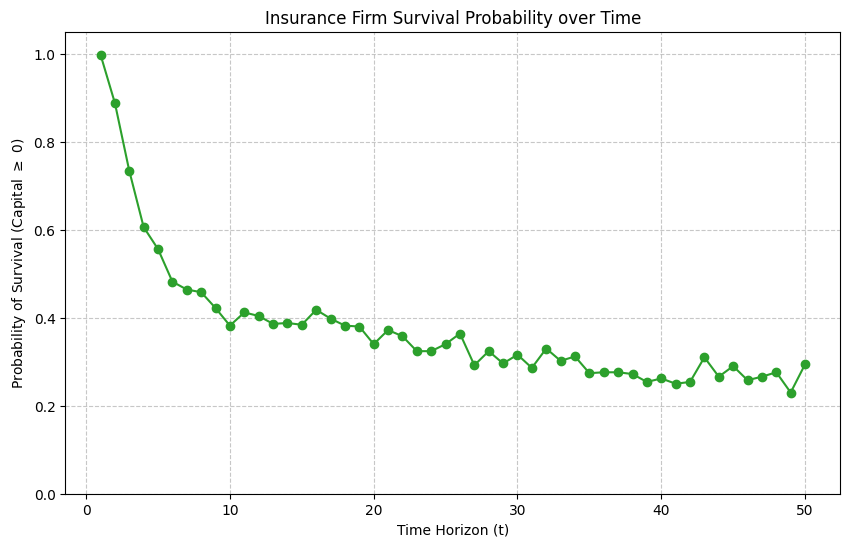

In [10]:
import matplotlib.pyplot as plt
### This part is a demonstration using constant claim amounts

# 1. Define a constant claim distribution function
CLAIM_CONSTANT = 25

def constant_claim_dist():
    return CLAIM_CONSTANT

# 2. Set up our parameters
# You can tweak these to see how they change the curve
cRate = 0.5            # Claim rate per customer
sRate = 0.9            # New customer sign-up rate
rRate = 0.5            # Customer departure rate
pRate = 10.0           # Premium paid per customer per unit time
initialCapital = 1000  # Starting money
initialCustomer = 20   # Starting customers

# Instantiate the simulation object
my_sim = simulation(cRate, sRate, rRate, pRate, constant_claim_dist, initialCapital, initialCustomer)

# 3. Define the time horizons to test
max_time = 50
time_points = list(range(1, max_time + 1))
survival_probabilities = []
simulations_per_point = 500 # Increase this for a smoother curve, decrease for speed

print(f"Running {simulations_per_point} simulations per time point...")

# 4. Calculate the probability for each time point
for t in time_points:
    # We call your computeProbability method
    prob = my_sim.computeProbability(time=t, simCount=simulations_per_point)
    survival_probabilities.append(prob)
    print(f"Time t={t} | Survival Rate: {prob:.4f}")

# 5. Plot the results using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(time_points, survival_probabilities, marker='o', linestyle='-', color='#2ca02c')

plt.title('Insurance Firm Survival Probability over Time')
plt.xlabel('Time Horizon (t)')
plt.ylabel('Probability of Survival (Capital $\geq$ 0)')
plt.ylim([0, 1.05]) # Lock Y-axis between 0 and 100%
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()